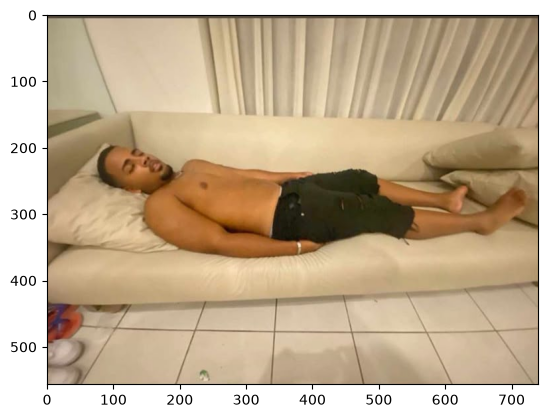

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

MAX_ITER = 50

img_path = "/home/lucian/faculdade_6_semestre/engenharia-programas/programando_k-means_atividade_2/img/img.jpeg"

img  = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

plt.show()

Tamanho do c 3


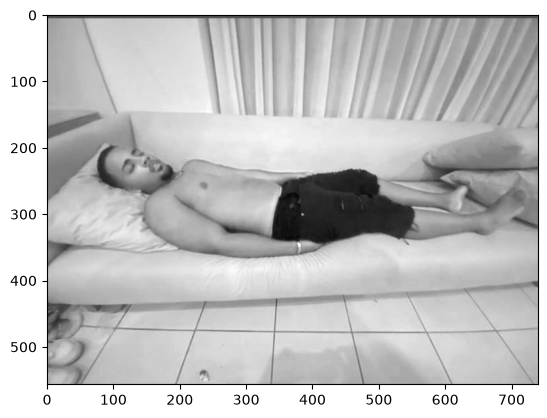

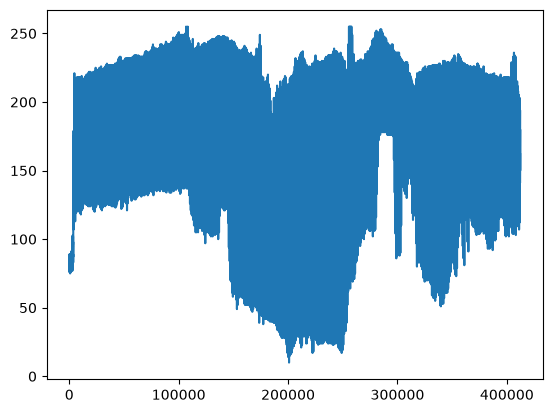

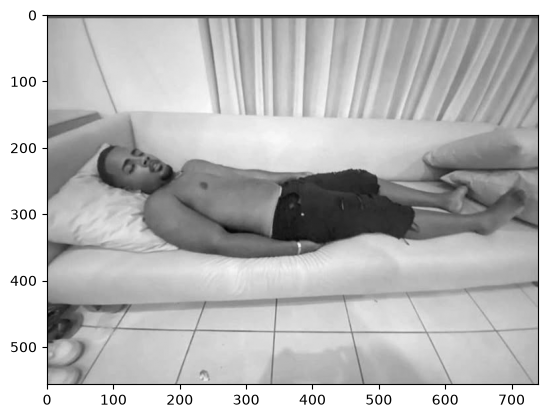

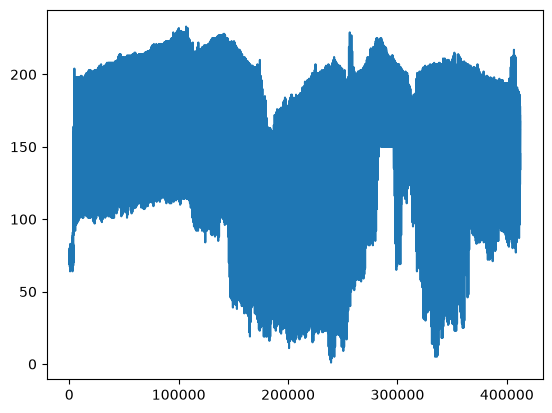

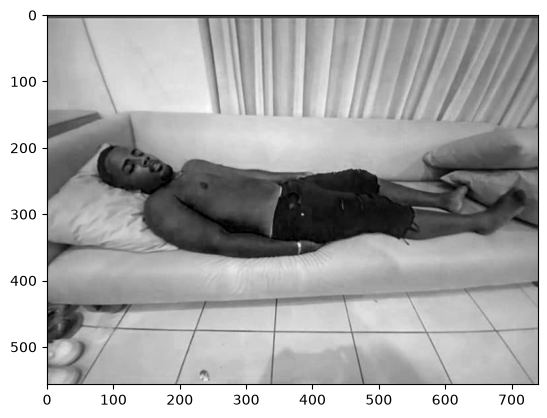

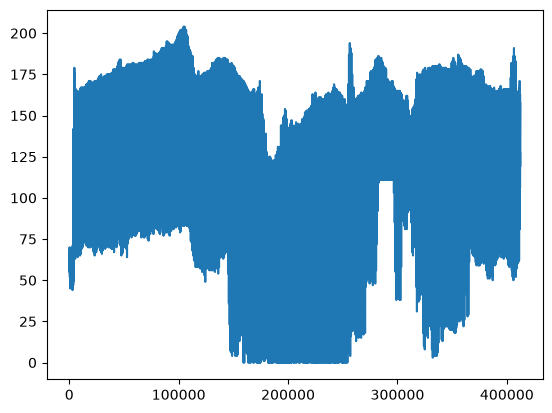

In [12]:
K = 2

n, m, c = img.shape

plano = []

faixa = []

print(f"Tamanho do c {c}")

for cor in range(c):
    plano.append(img[:,:,cor])
    plt.imshow(plano[-1], cmap='gray')
    plt.show()
    faixa.append(plano[-1].flatten())

    plt.plot(faixa[-1])
    plt.show()

In [13]:
centroid = []
v = []
n_pixels = len(faixa[0])

for k in range(K):
    px = np.random.randint(0, n_pixels)
    v0 = faixa[0][px]
    v1 = faixa[1][px]
    v2 = faixa[2][px]
    centroid.append([v0,v1,v2])
    print(f"centroid[{k}] = {centroid[k]}")


centroid[0] = [np.uint8(211), np.uint8(187), np.uint8(159)]
centroid[1] = [np.uint8(187), np.uint8(166), np.uint8(135)]


In [14]:
conv = False
number_iter = 0



CLUSTER = [[] for _ in range(K)]
while(conv == False and number_iter <= MAX_ITER):
    for px in range(n_pixels):
        v = [faixa[0][px],faixa[1][px],faixa[2][px]]
        d = []
        
        for k in range(K):
            d.append(np.linalg.norm(np.array(v) - np.array(centroid[k])))
        
        cluster = np.argmin(d)
        CLUSTER[cluster].append(px)

    for k in range(K):
        print(f"Tamanho cluster {k+1}: {len(CLUSTER[k])}")

    new_centroid = []

    for k in range(K):
        L = len(CLUSTER[k])
        s = np.zeros(3)
        for px in CLUSTER[k]:
            s += [faixa[0][px],faixa[1][px],faixa[2][px]]
        
        new_centroid.append([int(s[0]/L),int(s[1]/L),int(s[2]/L)])

    print(f"Novos centroids {new_centroid}")

    for k in range(K):
        for c in range(3):
            
            if centroid[k][c] != new_centroid[k][c]:
                print("CENTROIDS SÃO DIFERENETES")
                centroid = new_centroid
                break 

            conv = True
            print(f"Convergiu em {number_iter} interações")

        if centroid == new_centroid:
            break 
        
    number_iter+=1
    

Tamanho cluster 1: 238442
Tamanho cluster 2: 173738
Novos centroids [[170, 144, 109], [201, 176, 140]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 399856
Tamanho cluster 2: 424504
Novos centroids [[159, 131, 96], [205, 182, 147]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 548556
Tamanho cluster 2: 687984
Novos centroids [[154, 126, 90], [206, 183, 148]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 690644
Tamanho cluster 2: 958076
Novos centroids [[151, 122, 86], [206, 183, 148]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 827002
Tamanho cluster 2: 1233898
Novos centroids [[149, 119, 83], [206, 183, 149]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 960192
Tamanho cluster 2: 1512888
Novos centroids [[147, 117, 81], [206, 183, 149]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 1090803
Tamanho cluster 2: 1794457
Novos centroids [[146, 116, 79], [206, 183, 149]]
CENTROIDS SÃO DIFERENETES
Tamanho cluster 1: 1219494
Tamanho cluster 2: 2077946
Novos centroids [[145, 114, 78], [205, 183, 1

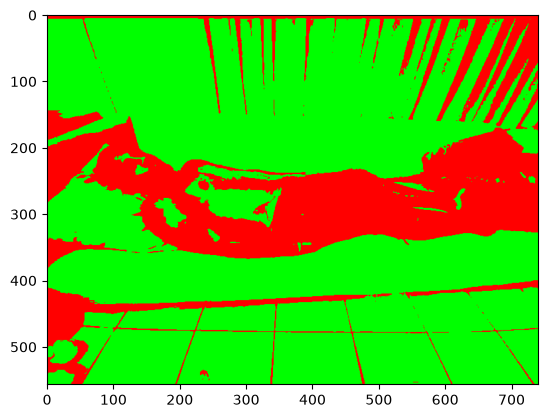

In [17]:

color = [[255,0,0], [0,255,0], [0,0,255]]
segmented = np.empty((n, m, 3), dtype=np.uint8)

for k in range(K):
    for px in CLUSTER[k]:
        i = px // m
        j = px % m
        segmented[i,j] = color[k]
plt.imshow(segmented)
plt.show()